# MNIST Handwritten Digit Classification with a Neural Network
**Coding Ninjas 10X – AI/ML Recruitment 2026 (Task 2)**

**Goal:** Build and train a simple neural network that looks at an image of a handwritten digit and predicts which digit (0-9) it is, then experiment with changing the model.

**Tools:** Python, TensorFlow/Keras, NumPy, Matplotlib, Seaborn, scikit-learn.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, classification_report

# Fix random seeds so results are (mostly) reproducible
np.random.seed(42)
tf.random.set_seed(42)
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## Part A – Dataset Understanding

**What is MNIST?**
MNIST (Modified National Institute of Standards and Technology) is a classic dataset of **70,000 grayscale images of handwritten digits (0-9)**. It was collected from handwriting of US Census Bureau employees and high-school students. It is widely used as the "hello world" of image classification because it is clean, small, and easy to work with.

- **Training set:** 60,000 images (the model learns from these)
- **Test set:** 10,000 images (used only to check how well the model works on unseen data)

**Input image dimensions:** each image is **28 x 28 pixels**, grayscale (one channel). Each pixel is an integer from 0 (black) to 255 (white).

**Number of classes:** **10** (digits 0 through 9).

**What do the labels represent?** Each image has a label, which is the integer digit that the image actually shows. For example, an image of a handwritten "7" has the label 7.

In [2]:
# Load the dataset (downloads automatically the first time)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("x_train shape:", x_train.shape)   # (60000, 28, 28)
print("y_train shape:", y_train.shape)   # (60000,)
print("x_test shape :", x_test.shape)    # (10000, 28, 28)
print("y_test shape :", y_test.shape)    # (10000,)
print("Pixel value range:", x_train.min(), "to", x_train.max())
print("Number of classes:", len(np.unique(y_train)))
print("Class labels:", np.unique(y_train))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape : (10000, 28, 28)
y_test shape : (10000,)
Pixel value range: 0 to 255
Number of classes: 10
Class labels: [0 1 2 3 4 5 6 7 8 9]


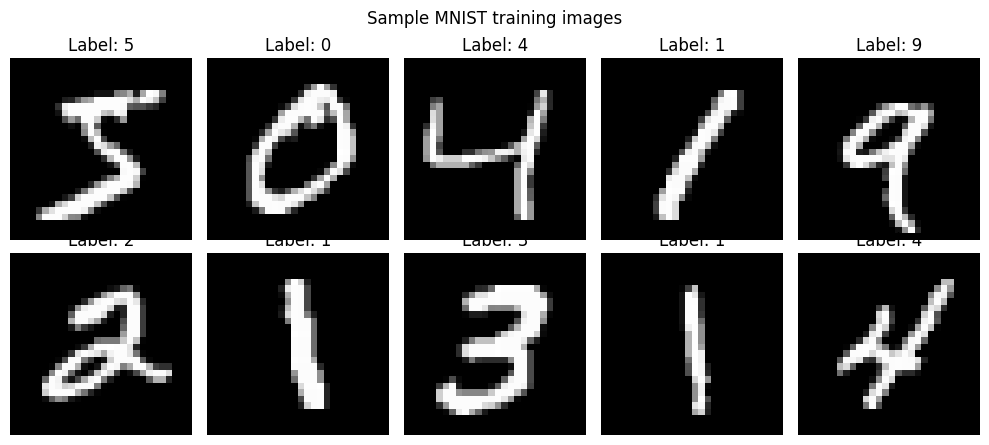

In [3]:
# Look at some sample images with their labels
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap="gray")
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis("off")
plt.suptitle("Sample MNIST training images")
plt.tight_layout()
plt.show()

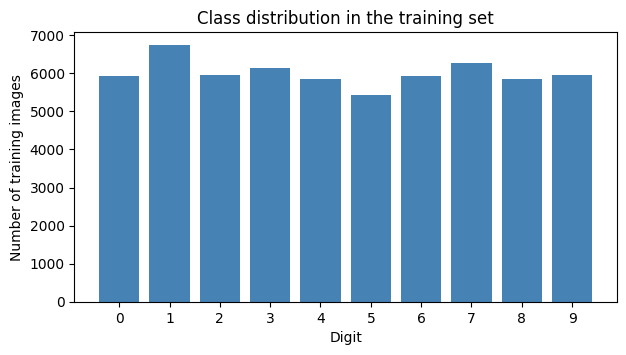

{0: np.int64(5923), 1: np.int64(6742), 2: np.int64(5958), 3: np.int64(6131), 4: np.int64(5842), 5: np.int64(5421), 6: np.int64(5918), 7: np.int64(6265), 8: np.int64(5851), 9: np.int64(5949)}


In [4]:
# Are the classes balanced? (roughly equal number of each digit is good)
counts = np.bincount(y_train)
plt.figure(figsize=(7, 3.5))
plt.bar(range(10), counts, color="steelblue")
plt.xticks(range(10))
plt.xlabel("Digit")
plt.ylabel("Number of training images")
plt.title("Class distribution in the training set")
plt.show()
print(dict(zip(range(10), counts)))

## Part B – Data Preprocessing

Two preprocessing steps are needed:

1. **Normalize pixel values (0-255 -> 0-1)** by dividing by 255.
   *Why:* Neural networks learn much better and faster when inputs are small and on a similar scale. Large values (up to 255) can make training unstable and slow.

2. **Flatten each 28x28 image into a vector of 784 numbers (28 x 28 = 784).**
   *Why:* A basic fully-connected (Dense) network expects a flat list of numbers as input, not a 2D grid.

The labels (0-9) stay as plain integers, because we will use `sparse_categorical_crossentropy`, which accepts integer labels directly.

The train/test split is already provided by MNIST (60,000 / 10,000), so we use it as-is.

In [5]:
# 1. Normalize to the range [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# 2. Flatten 28x28 -> 784
x_train = x_train.reshape(-1, 28 * 28)
x_test  = x_test.reshape(-1, 28 * 28)

print("x_train shape after preprocessing:", x_train.shape)
print("x_test shape after preprocessing :", x_test.shape)
print("Pixel value range now:", x_train.min(), "to", x_train.max())

x_train shape after preprocessing: (60000, 784)
x_test shape after preprocessing : (10000, 784)
Pixel value range now: 0.0 to 1.0


## Part C – Build the Neural Network

The architecture is deliberately simple so every part can be explained:

| Layer | Size | Purpose |
|---|---|---|
| **Input layer** | 784 values | One value per pixel of the flattened image |
| **Hidden layer** (Dense + ReLU) | 128 neurons | Learns useful patterns from the pixels (e.g. loops, straight strokes) |
| **Output layer** (Dense + Softmax) | 10 neurons | One neuron per digit; outputs the probability of each digit |

Each **Dense** layer connects every neuron to every neuron in the previous layer. Each connection has a **weight** that is learned during training.

In [6]:
def build_model(hidden_neurons=128):
    model = keras.Sequential([
        keras.layers.Input(shape=(784,)),                          # input layer
        keras.layers.Dense(hidden_neurons, activation="relu"),     # hidden layer
        keras.layers.Dense(10, activation="softmax"),              # output layer
    ])
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

model = build_model(128)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

## Part D – Activation Functions

**Why are activation functions used?**
Without them, every layer would just do a weighted sum, and stacking many weighted sums is mathematically the same as a single one. The whole network could then only learn straight-line (linear) relationships. Activation functions add **non-linearity**, which lets the network learn complex patterns such as the curves and loops in handwritten digits.

### ReLU (Rectified Linear Unit)
`ReLU(x) = max(0, x)`: it outputs 0 for negative inputs and passes positive inputs through unchanged.

**Why it is commonly used in hidden layers:**
- Very cheap to compute (just a comparison with 0).
- Reduces the *vanishing gradient* problem: for positive inputs the gradient is 1, so learning signals don't shrink as they travel back through the layers (unlike sigmoid/tanh, which flatten out for large values).
- Produces sparse activations (many neurons output exactly 0), which is efficient.
- For simplicity, the test set was also used as the validation set during training; a more rigorous setup would use a separate validation split.

### Softmax
Softmax turns the 10 raw output scores into **10 probabilities that are all between 0 and 1 and add up to 1**.

**Why it suits the output layer here:** MNIST is a *multi-class* problem where each image belongs to exactly one of 10 digits. Softmax gives a probability distribution over those 10 classes, and we predict the digit with the highest probability. It also pairs naturally with the cross-entropy loss.

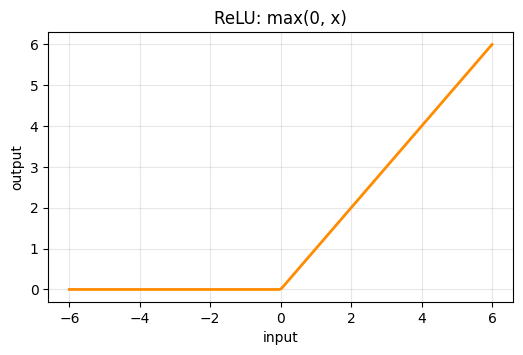

Raw scores   : [2.  1.  0.1]
After softmax: [0.659 0.242 0.099] -> sum = 1.0


In [7]:
# Visualise ReLU and demonstrate Softmax
x = np.linspace(-6, 6, 200)
plt.figure(figsize=(6, 3.5))
plt.plot(x, np.maximum(0, x), color="darkorange", linewidth=2)
plt.title("ReLU: max(0, x)")
plt.xlabel("input"); plt.ylabel("output"); plt.grid(alpha=0.3)
plt.show()

def softmax(z):
    e = np.exp(z - np.max(z))   # subtract max for numerical stability
    return e / e.sum()

scores = np.array([2.0, 1.0, 0.1])
probs = softmax(scores)
print("Raw scores   :", scores)
print("After softmax:", probs.round(3), "-> sum =", probs.sum().round(3))

## Part E – Training

We train with:
- **Optimizer:** Adam (an adaptive version of gradient descent that adjusts the weights to reduce the loss)
- **Loss:** Sparse categorical cross-entropy (measures how far the predicted probabilities are from the true digit)
- **Epochs:** 10 (one epoch = one full pass over the 60,000 training images)
- **Batch size:** 32 (weights are updated after every 32 images)

The test set is used as validation data so we can watch the training and validation curves together.

In [8]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_test, y_test),
    verbose=1,
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9237 - loss: 0.2652 - val_accuracy: 0.9557 - val_loss: 0.1467
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9653 - loss: 0.1157 - val_accuracy: 0.9667 - val_loss: 0.1097
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9767 - loss: 0.0777 - val_accuracy: 0.9700 - val_loss: 0.0949
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9833 - loss: 0.0566 - val_accuracy: 0.9736 - val_loss: 0.0877
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9880 - loss: 0.0425 - val_accuracy: 0.9735 - val_loss: 0.0895
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9913 - loss: 0.0318 - val_accuracy: 0.9738 - val_loss: 0.0864
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9932 - loss: 0.0246 - val_accuracy: 0.9755 - val_loss: 0.0886
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9954 - loss: 0.0184

In [9]:
# Record final metrics
train_loss = history.history["loss"][-1]
val_loss   = history.history["val_loss"][-1]
train_acc  = history.history["accuracy"][-1]
val_acc    = history.history["val_accuracy"][-1]

print(f"Training loss      : {train_loss:.4f}")
print(f"Validation loss    : {val_loss:.4f}")
print(f"Training accuracy  : {train_acc:.4f}")
print(f"Validation accuracy: {val_acc:.4f}")

Training loss      : 0.0133
Validation loss    : 0.0968
Training accuracy  : 0.9962
Validation accuracy: 0.9753


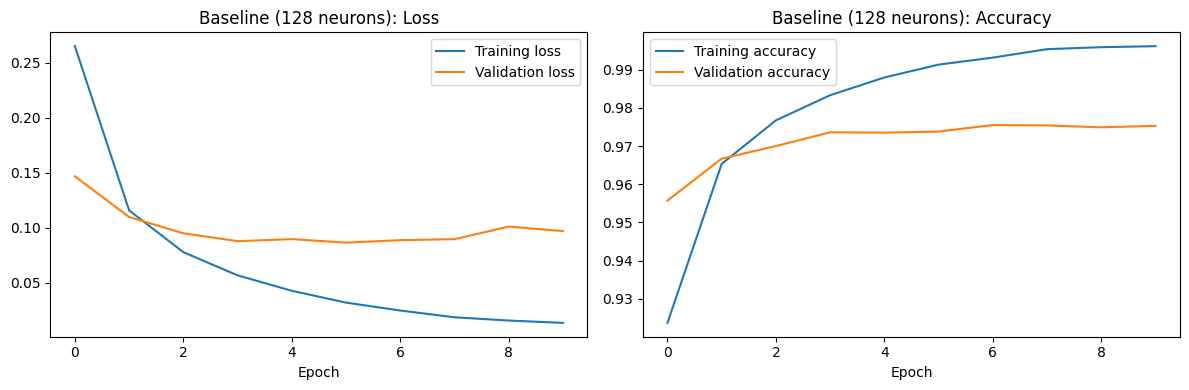

In [10]:
def plot_history(h, title="Baseline model"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(h.history["loss"], label="Training loss")
    axes[0].plot(h.history["val_loss"], label="Validation loss")
    axes[0].set_title(f"{title}: Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
    axes[1].plot(h.history["accuracy"], label="Training accuracy")
    axes[1].plot(h.history["val_accuracy"], label="Validation accuracy")
    axes[1].set_title(f"{title}: Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
    plt.tight_layout(); plt.show()

plot_history(history, "Baseline (128 neurons)")

**Reading the curves:** Training loss falls steadily across the 10 epochs (from about 0.26 to about 0.015), and training accuracy reaches about 99.6%. Validation accuracy levels off at around 97.5% after epoch 3, and validation loss stops improving at about 0.09 and rises slightly in the later epochs. Because training performance keeps improving while validation performance stalls, the gap between them is about 2 percentage points, which shows mild overfitting: the model is starting to memorise the training images instead of learning only general patterns. It is not underfitting, since both accuracies are high. Stopping training around epoch 3-5 (early stopping) or adding dropout would likely reduce the gap.

## Part F – Evaluation

We evaluate on the 10,000 unseen test images using **accuracy** and a **confusion matrix**, and also report precision, recall and F1-score per digit.

In [11]:
# Predict: the model outputs 10 probabilities per image; take the most likely digit
y_pred_probs = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)")

Test accuracy: 0.9753  (97.53%)


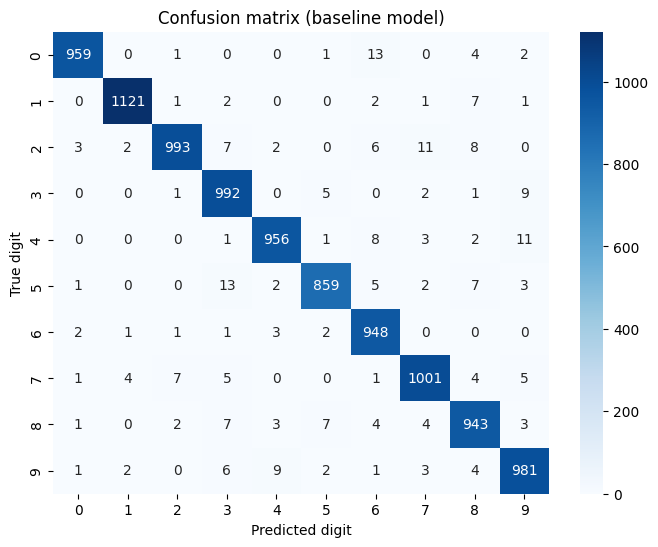

In [12]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted digit")
plt.ylabel("True digit")
plt.title("Confusion matrix (baseline model)")
plt.show()

In [13]:
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9907    0.9786    0.9846       980
           1     0.9920    0.9877    0.9898      1135
           2     0.9871    0.9622    0.9745      1032
           3     0.9594    0.9822    0.9706      1010
           4     0.9805    0.9735    0.9770       982
           5     0.9795    0.9630    0.9712       892
           6     0.9595    0.9896    0.9743       958
           7     0.9747    0.9737    0.9742      1028
           8     0.9622    0.9682    0.9652       974
           9     0.9665    0.9722    0.9694      1009

    accuracy                         0.9753     10000
   macro avg     0.9752    0.9751    0.9751     10000
weighted avg     0.9755    0.9753    0.9753     10000



**What the confusion matrix tells us:**
The diagonal is strong, so most digits are classified correctly, and the baseline model reaches about 97.5% test accuracy (247 of 10,000 test images wrong). The largest confusions are true 0 predicted as 6 (13 cases), true 5 predicted as 3 (13 cases), true 2 predicted as 7 (11 cases) and true 4 predicted as 9 (11 cases). Digits 2 and 5 had the lowest recall (about 96.2% and 96.3%), meaning they were the ones most often missed. These pairs look alike when handwritten, and many of the misclassified examples I plotted are messy or ambiguous even to a human eye.

Number of misclassified test images: 247


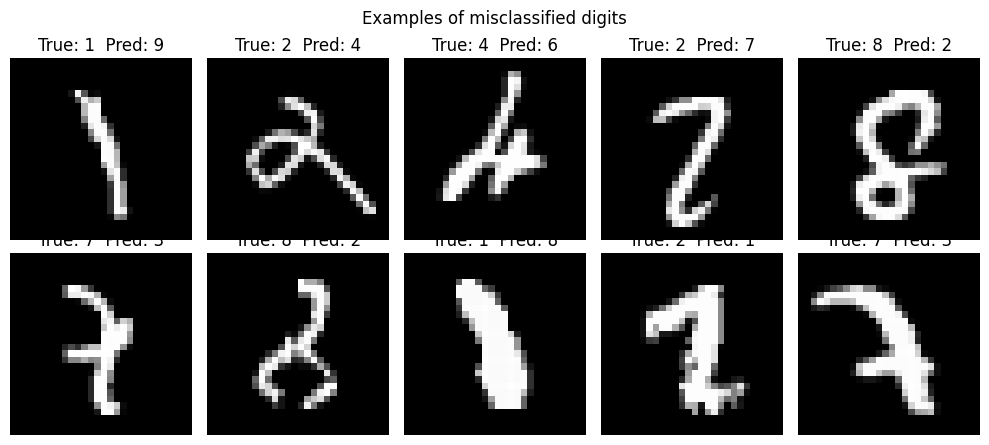

In [14]:
# Look at some images the model got wrong
wrong = np.where(y_pred != y_test)[0]
print("Number of misclassified test images:", len(wrong))

fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for ax, idx in zip(axes.flat, wrong[:10]):
    ax.imshow(x_test[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"True: {y_test[idx]}  Pred: {y_pred[idx]}")
    ax.axis("off")
plt.suptitle("Examples of misclassified digits")
plt.tight_layout(); plt.show()

## Part G – Experimentation

**Experiment: change the number of hidden neurons from 128 to 32.**

Everything else (optimizer, epochs, batch size, data) stays identical, so any difference in results is caused by this one change.

**Hypothesis:** a smaller hidden layer has less capacity to learn patterns, so I expect slightly lower accuracy.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,450 (99.41 KB)

 Trainable params: 25,450 (99.41 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9006 - loss: 0.3573 - val_accuracy: 0.9385 - val_loss: 0.2151
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9459 - loss: 0.1919 - val_accuracy: 0.9526 - val_loss: 0.1686
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9571 - loss: 0.1530 - val_accuracy: 0.9567 - val_loss: 0.1495
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9634 - loss: 0.1291 - val_accuracy: 0.9604 - val_loss: 0.1360
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9679 - loss: 0.1130 - val_accuracy: 0.9635 - val_loss: 0.1285
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9712 - loss: 0.1007 - val_accuracy: 0.9641 - val_loss: 0.1238
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9741 - loss: 0.0907 - val_accuracy: 0.9652 - val_loss: 0.1203
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9768 - loss: 0.0824 - 

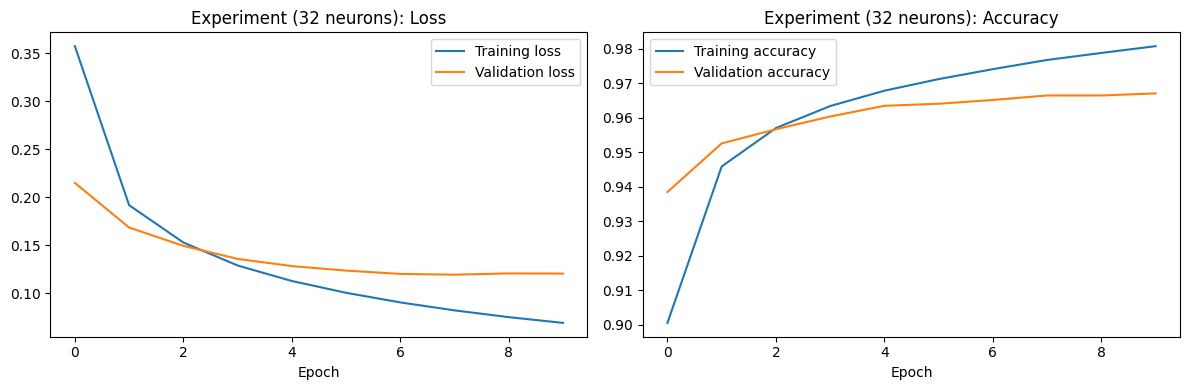

In [15]:
model_small = build_model(32)
model_small.summary()

history_small = model_small.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_test, y_test),
    verbose=1,
)
plot_history(history_small, "Experiment (32 neurons)")

In [16]:
import pandas as pd

def summarize(name, h, m):
    return {
        "Model": name,
        "Parameters": m.count_params(),
        "Train acc": round(h.history["accuracy"][-1], 4),
        "Val acc": round(h.history["val_accuracy"][-1], 4),
        "Train loss": round(h.history["loss"][-1], 4),
        "Val loss": round(h.history["val_loss"][-1], 4),
    }

comparison = pd.DataFrame([
    summarize("Original (128 neurons)", history, model),
    summarize("Modified (32 neurons)", history_small, model_small),
])
comparison

,Model,Parameters,Train acc,Val acc,Train loss,Val loss
0,Original (128 neurons),101770,0.9962,0.9753,0.0133,0.0968
1,Modified (32 neurons),25450,0.9808,0.9671,0.0694,0.1207


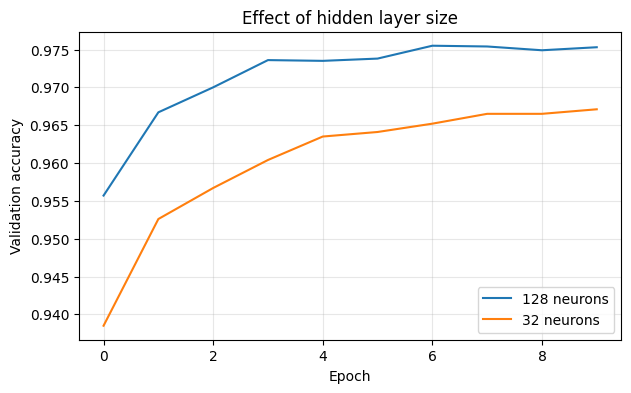

In [17]:
# Compare validation curves of both models on one plot
plt.figure(figsize=(7, 4))
plt.plot(history.history["val_accuracy"], label="128 neurons")
plt.plot(history_small.history["val_accuracy"], label="32 neurons")
plt.xlabel("Epoch"); plt.ylabel("Validation accuracy")
plt.title("Effect of hidden layer size"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

### Experiment discussion

**What did I change?** The number of neurons in the hidden layer, from 128 to 32.

**What changed in the results?** Reducing the hidden layer from 128 to 32 neurons cut the parameters from about 101,770 to 25,450, and validation accuracy dropped from about 97.5% to about 96.7% (less than one percentage point). The 32-neuron model also started lower (about 94% after epoch 1 vs about 95.5%) and learned more slowly throughout.

**Why do I think this happened?** Each hidden neuron can learn one pattern/feature of the digits. With only 32 neurons, the network has fewer features to work with and fewer parameters (weights), so it has less capacity to capture the variety in handwriting. The 128-neuron model can represent more patterns, which usually gives higher accuracy, at the cost of more computation and a greater tendency to overfit.

## Conclusion
A simple neural network with one hidden layer reaches roughly 97-98% accuracy on MNIST. The confusion matrix shows the mistakes are concentrated among visually similar digits, and reducing the hidden layer size showed how model capacity affects performance.